Football Player Future G/A Predictor

Importing Modules

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

Reading the Data

In [2]:
df23 = pd.read_csv('ModelData/football-data_23-24.csv') 
df24 = pd.read_csv('ModelData/football-data_24-25.csv')
df25 = pd.read_csv('ModelData/football-data_25-26.csv')

print(f"2023-2024 shape: {df23.shape}")
print(f"2024-2025 shape: {df24.shape}")
print(f"2025-2026 shape: {df25.shape}")

2023-2024 shape: (2852, 37)
2024-2025 shape: (2854, 267)
2025-2026 shape: (2779, 102)


Preparing and Cleaning the data

In [3]:
base_features = ['Min', '90s', 'Gls', 'Ast', 'G+A', 'xG', 'npxG', 'xAG', 'PrgC', 'PrgP', 'PrgR']

df23_sub = df23[['Player', 'Age', 'Pos'] + base_features]
df23_sub = df23_sub.add_suffix('_23')
df23_sub = df23_sub.rename(columns={'Player_23': 'Player'})

df24_sub = df24[['Player'] + base_features]
df24_sub = df24_sub.add_suffix('_24')
df24_sub = df24_sub.rename(columns={'Player_24': 'Player'})

df25_target = df25[['Player', 'G+A', '90s']].copy()
df25_target = df25_target.rename(columns={'G+A': 'Target_G+A', '90s': '90s_25'})
df25_target['Target_GA_per90'] = df25_target['Target_G+A'] / df25_target['90s_25']

cleandf = df23_sub.merge(df24_sub, on='Player', how='inner').merge(df25_target, on='Player', how='inner')
cleandf = cleandf.drop_duplicates(subset=['Player'])

cleandf = cleandf[(cleandf['90s_24'] >= 10) & (cleandf['90s_23'] >= 5)].copy()
cleandf['Age_current'] = cleandf['Age_23'].astype(float) + 2

for season in ['23', '24']:
    cleandf[f'GA_per90_{season}']  = cleandf[f'G+A_{season}']  / cleandf[f'90s_{season}']
    cleandf[f'xG_per90_{season}']  = cleandf[f'xG_{season}']   / cleandf[f'90s_{season}']
    cleandf[f'xAG_per90_{season}'] = cleandf[f'xAG_{season}']  / cleandf[f'90s_{season}']

cleandf['GA_consistency'] = (cleandf['GA_per90_24'] + cleandf['GA_per90_23']) / 2
cleandf['GA_volatility'] = abs(cleandf['GA_per90_24'] - cleandf['GA_per90_23'])
cleandf['xG_consistency']  = (cleandf['xG_per90_24']  + cleandf['xG_per90_23'])  / 2
cleandf['xG_volatility']   = abs(cleandf['xG_per90_24']  - cleandf['xG_per90_23'])
cleandf['xAG_consistency'] = (cleandf['xAG_per90_24'] + cleandf['xAG_per90_23']) / 2
cleandf['xAG_volatility']  = abs(cleandf['xAG_per90_24'] - cleandf['xAG_per90_23'])

cleandf['GA_trend'] = cleandf['GA_per90_24'] - cleandf['GA_per90_23']
cleandf['xG_trend'] = cleandf['xG_per90_24'] - cleandf['xG_per90_23']
cleandf['xAG_trend'] = cleandf['xAG_per90_24'] - cleandf['xAG_per90_23']

le = LabelEncoder()
cleandf['Pos_encoded'] = le.fit_transform(cleandf['Pos_23'].fillna('Unknown'))

print(f"Players after filter: {cleandf.shape[0]}")


Players after filter: 921


Training the model using the Test Data using the Random Forest Regressor

In [4]:
features = ['Age_current', 'Pos_encoded', '90s_23', '90s_24','GA_per90_23', 'xG_per90_23', 'xAG_per90_23',
'GA_per90_24', 'xG_per90_24', 'xAG_per90_24','GA_consistency', 'GA_volatility', 'GA_trend', 'xG_consistency', 'xG_volatility', 'xG_trend',
'xAG_consistency', 'xAG_volatility', 'xAG_trend','PrgC_24', 'PrgP_24', 'PrgR_24']

X = cleandf[features].fillna(0)
y = cleandf['Target_GA_per90'].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_per90 = rf_model.predict(X_test)

results = cleandf.loc[X_test.index, ['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()
results['Predicted_GA_per90'] = y_pred_per90
results['Projected_G+A'] = results['Predicted_GA_per90'] * results['90s_25']

mae = mean_absolute_error(results['Target_G+A'], results['Projected_G+A'])
print(f"Model Accuracy (MAE): {mae:.3f} Goals/Assists off on average\n")

top_predictions = results.sort_values(by='Projected_G+A', ascending=False)

print("🏆 Model's Top 10 Predictions for the 25/26 Season (Test Set):")
print(top_predictions.head(10).to_string(index=False))

Model Accuracy (MAE): 1.671 Goals/Assists off on average

🏆 Model's Top 10 Predictions for the 25/26 Season (Test Set):
                    Player Pos_23  Target_G+A  90s_25  Predicted_GA_per90  Projected_G+A
              Ante Budimir     FW          17    29.6            0.903626      26.747336
           Mason Greenwood  MF,FW          21    25.4            0.904299      22.969192
           Serhou Guirassy     FW          17    25.1            0.831413      20.868465
           Vinicius Júnior     FW          20    28.4            0.606464      17.223583
                João Pedro  FW,MF          20    27.6            0.520859      14.375718
          Federico Dimarco     DF          22    29.1            0.454129      13.215160
Andre-Frank Zambo Anguissa     MF           5    14.0            0.927381      12.983337
                Yann Gboho  MF,FW          10    27.9            0.452430      12.622808
            Julián Álvarez  MF,FW          12    21.1            0.591344      

Final Predictions using the Entire Dataset

In [5]:
all_predictions_per90 = rf_model.predict(X)
global_results = cleandf[['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()

global_results['Predicted_GA_per90'] = all_predictions_per90
global_results['Projected_G+A'] = global_results['Predicted_GA_per90'] * global_results['90s_25']

mae2 = mean_absolute_error(global_results['Target_G+A'], global_results['Projected_G+A'])
print(f"Model Accuracy (MAE2): {mae2:.3f} Goals/Assists off on average\n")

global_top = global_results.sort_values(by='Projected_G+A', ascending=False)

print("🌍 GLOBAL TOP 10 PREDICTIONS (Entire Dataset):")
print(global_top[['Player', 'Pos_23', 'Target_G+A', 'Projected_G+A']].head(10).to_string(index=False))

Model Accuracy (MAE2): 1.277 Goals/Assists off on average

🌍 GLOBAL TOP 10 PREDICTIONS (Entire Dataset):
         Player Pos_23  Target_G+A  Projected_G+A
     Harry Kane     FW          38      31.429559
  Kylian Mbappé     FW          28      27.521128
 Erling Haaland     FW          32      26.941093
   Ante Budimir     FW          17      26.747336
  Michael Olise  FW,MF          33      24.884801
Mason Greenwood  MF,FW          21      22.969192
   Lamine Yamal     FW          27      22.675225
Serhou Guirassy     FW          17      20.868465
    Deniz Undav  FW,MF          24      20.327843
      Luis Díaz     FW          28      20.150753


Testing the Model using the Gradient Bossting Regressor

In [6]:
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb_per90 = gb_model.predict(X_test)

test_results_gb = cleandf.loc[X_test.index, ['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()
test_results_gb['Predicted_GA_per90'] = y_pred_gb_per90
test_results_gb['Projected_G+A'] = test_results_gb['Predicted_GA_per90'] * test_results_gb['90s_25']

gb_mae = mean_absolute_error(test_results_gb['Target_G+A'], test_results_gb['Projected_G+A'])
print(f"Gradient Boosting Accuracy (Test MAE): {gb_mae:.3f} Goals/Assists off on average\n")

all_predictions_gb_per90 = gb_model.predict(X)
global_results_gb = cleandf[['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()

global_results_gb['Predicted_GA_per90'] = all_predictions_gb_per90
global_results_gb['Projected_G+A'] = global_results_gb['Predicted_GA_per90'] * global_results_gb['90s_25']

global_top_gb = global_results_gb.sort_values(by='Projected_G+A', ascending=False)

print("🚀 GLOBAL TOP 10 PREDICTIONS (Gradient Boosting):")
print(global_top_gb[['Player', 'Pos_23', 'Target_G+A', 'Projected_G+A']].head(10).to_string(index=False))


Gradient Boosting Accuracy (Test MAE): 1.653 Goals/Assists off on average

🚀 GLOBAL TOP 10 PREDICTIONS (Gradient Boosting):
         Player Pos_23  Target_G+A  Projected_G+A
     Harry Kane     FW          38      35.303134
 Erling Haaland     FW          32      29.725923
  Michael Olise  FW,MF          33      29.612402
  Kylian Mbappé     FW          28      27.692110
   Lamine Yamal     FW          27      26.252049
   Ante Budimir     FW          17      23.739803
Bruno Fernandes  MF,FW          27      22.336596
      Luis Díaz     FW          28      21.653571
    Deniz Undav  FW,MF          24      21.427280
Serhou Guirassy     FW          17      19.079176


Testing the Model using the Extreme Gradient Boosting Regressor

In [7]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# X, y, cleandf, X_train, X_test, y_train, y_test are carried over from previous cells

# Initialize the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb_per90 = xgb_model.predict(X_test)

# Calculate MAE for the test set
test_results_xgb = cleandf.loc[X_test.index, ['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()
test_results_xgb['Predicted_GA_per90'] = y_pred_xgb_per90
test_results_xgb['Projected_G+A'] = test_results_xgb['Predicted_GA_per90'] * test_results_xgb['90s_25']

xgb_mae = mean_absolute_error(test_results_xgb['Target_G+A'], test_results_xgb['Projected_G+A'])
print(f"XGBoost Accuracy (Test MAE): {xgb_mae:.3f} Goals/Assists off on average\n")

# Final predictions using the entire dataset
all_predictions_xgb_per90 = xgb_model.predict(X)
global_results_xgb = cleandf[['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()

global_results_xgb['Predicted_GA_per90'] = all_predictions_xgb_per90
global_results_xgb['Projected_G+A'] = global_results_xgb['Predicted_GA_per90'] * global_results_xgb['90s_25']

global_top_xgb = global_results_xgb.sort_values(by='Projected_G+A', ascending=False)

print("⚡ GLOBAL TOP 10 PREDICTIONS (XGBoost):")
print(global_top_xgb[['Player', 'Pos_23', 'Target_G+A', 'Projected_G+A']].head(10).to_string(index=False))

XGBoost Accuracy (Test MAE): 1.671 Goals/Assists off on average

⚡ GLOBAL TOP 10 PREDICTIONS (XGBoost):
         Player Pos_23  Target_G+A  Projected_G+A
     Harry Kane     FW          38      33.648192
 Erling Haaland     FW          32      30.927722
  Michael Olise  FW,MF          33      30.438170
  Kylian Mbappé     FW          28      27.996697
   Lamine Yamal     FW          27      25.776508
      Luis Díaz     FW          28      25.171577
Serhou Guirassy     FW          17      23.135876
    Deniz Undav  FW,MF          24      21.976690
Bruno Fernandes  MF,FW          27      21.811701
   Ante Budimir     FW          17      21.023847


## 📊 Visualizations & Model Evaluation

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Set a clean style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'


### 1️⃣ Model Comparison — Test MAE

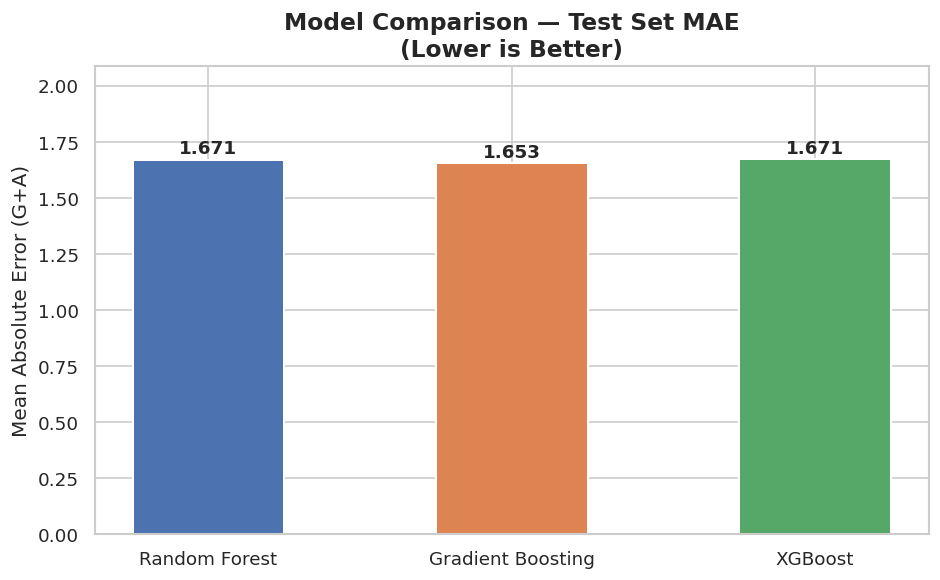

Best model: Gradient Boosting (MAE = 1.653)


In [9]:
# Collect MAE scores for all three models on the test set
models      = ['Random Forest', 'Gradient Boosting', 'XGBoost']
test_maes   = [mae, gb_mae, xgb_mae]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(models, test_maes, color=colors, width=0.5, edgecolor='white', linewidth=1.2)

# Annotate bars
for bar, val in zip(bars, test_maes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Mean Absolute Error (G+A)', fontsize=12)
ax.set_title('Model Comparison — Test Set MAE\n(Lower is Better)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(test_maes) * 1.25)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.savefig('model_comparison_mae.png', bbox_inches='tight')
plt.show()
print(f'Best model: {models[test_maes.index(min(test_maes))]} (MAE = {min(test_maes):.3f})')


### 2️⃣ Predicted vs Actual G+A — All Models

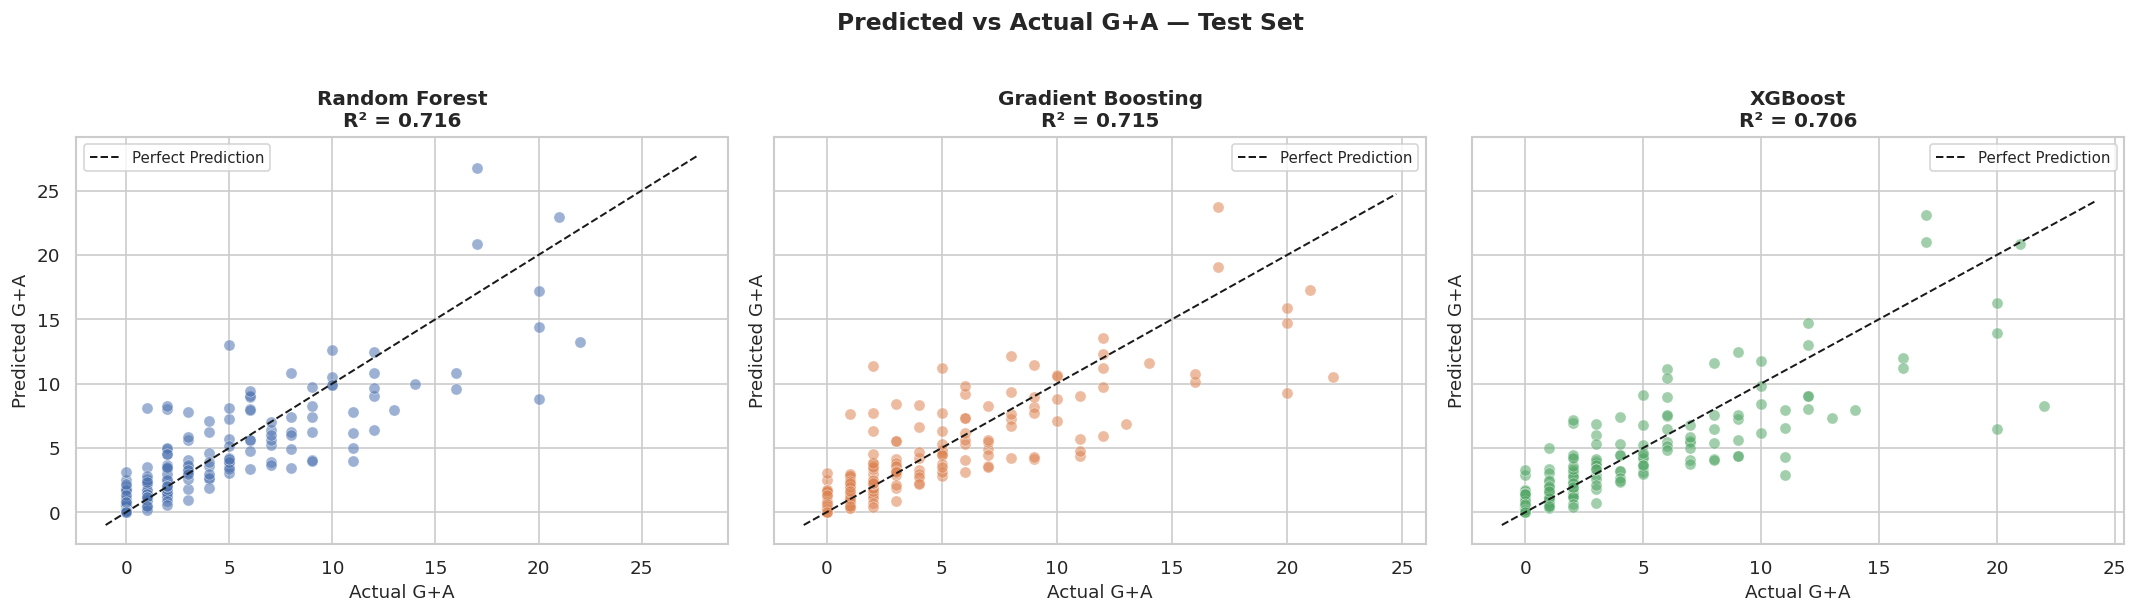

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

model_data = [
    ('Random Forest',      results,         '#4C72B0'),
    ('Gradient Boosting',  test_results_gb, '#DD8452'),
    ('XGBoost',            test_results_xgb,'#55A868'),
]

for ax, (name, df, color) in zip(axes, model_data):
    actual    = df['Target_G+A']
    predicted = df['Projected_G+A']
    r2 = r2_score(actual, predicted)
    
    ax.scatter(actual, predicted, alpha=0.55, color=color, edgecolors='white', linewidth=0.4, s=45)
    
    # Perfect-prediction line
    lims = [min(actual.min(), predicted.min()) - 1, max(actual.max(), predicted.max()) + 1]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual G+A', fontsize=11)
    ax.set_ylabel('Predicted G+A', fontsize=11)
    ax.set_title(f'{name}\nR² = {r2:.3f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual G+A — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', bbox_inches='tight')
plt.show()


### 3️⃣ Residuals Distribution (XGBoost)

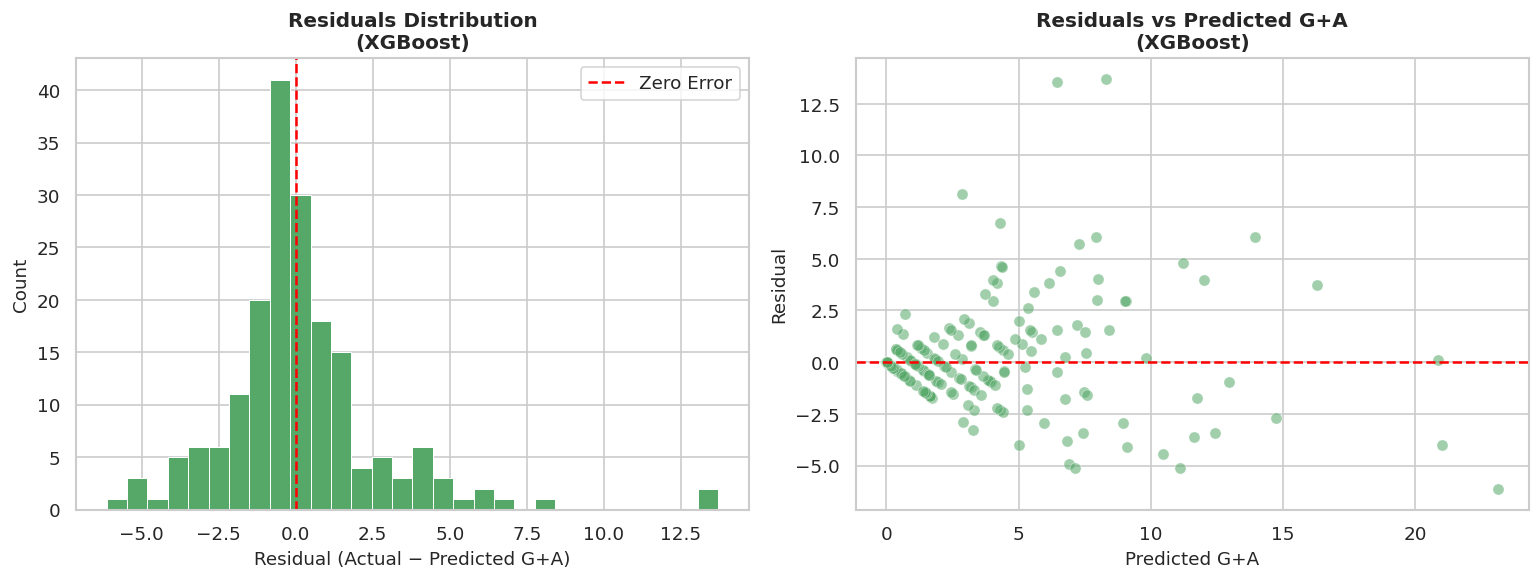

Mean Residual: 0.1748  |  Std: 2.6156


In [11]:
residuals_xgb = test_results_xgb['Target_G+A'] - test_results_xgb['Projected_G+A']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(residuals_xgb, bins=30, color='#55A868', edgecolor='white', linewidth=0.6)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')
axes[0].set_xlabel('Residual (Actual − Predicted G+A)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Residuals Distribution\n(XGBoost)', fontsize=12, fontweight='bold')
axes[0].legend()

# Residuals vs Predicted
axes[1].scatter(test_results_xgb['Projected_G+A'], residuals_xgb,
                alpha=0.55, color='#55A868', edgecolors='white', linewidth=0.4, s=45)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted G+A', fontsize=11)
axes[1].set_ylabel('Residual', fontsize=11)
axes[1].set_title('Residuals vs Predicted G+A\n(XGBoost)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('residuals_xgb.png', bbox_inches='tight')
plt.show()
print(f'Mean Residual: {residuals_xgb.mean():.4f}  |  Std: {residuals_xgb.std():.4f}')


### 4️⃣ Feature Importance — XGBoost

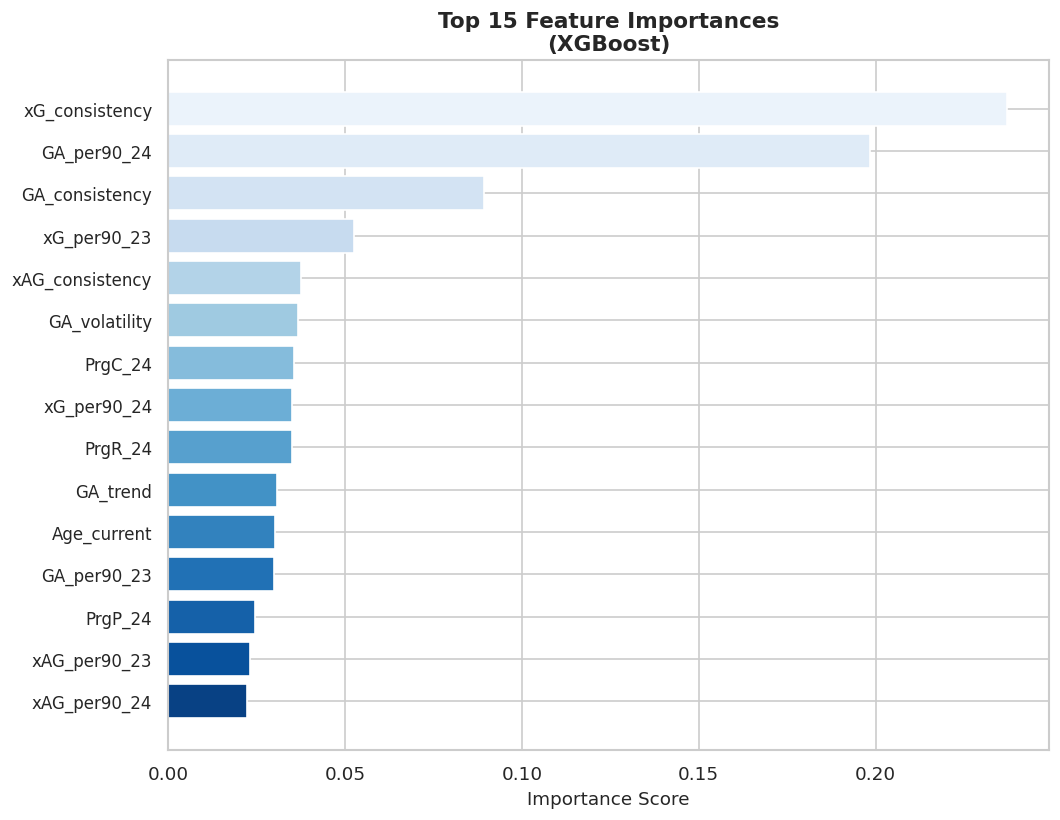

In [12]:
importances = xgb_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 7))
colors = sns.color_palette('Blues_r', len(feat_df))
ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Top 15 Feature Importances\n(XGBoost)', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', bbox_inches='tight')
plt.show()


### 5️⃣ Cross-Validation (5-Fold) — All Models

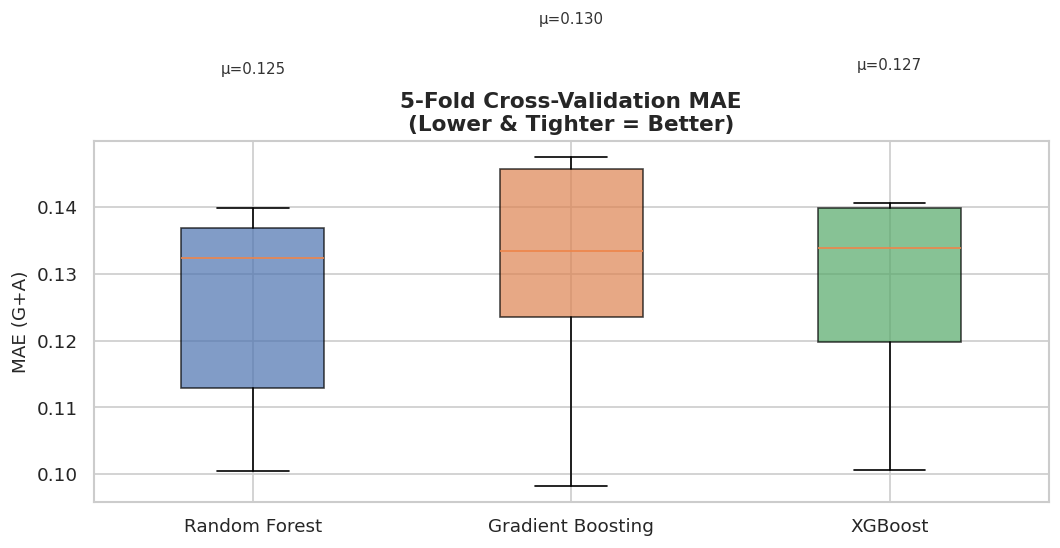

Cross-Validation Results:
  Random Forest        Mean MAE = 0.125  |  Std = 0.015
  Gradient Boosting    Mean MAE = 0.130  |  Std = 0.018
  XGBoost              Mean MAE = 0.127  |  Std = 0.015


In [13]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rf  = -cross_val_score(rf_model,  X, y, cv=kf, scoring='neg_mean_absolute_error')
cv_gb  = -cross_val_score(gb_model,  X, y, cv=kf, scoring='neg_mean_absolute_error')
cv_xgb = -cross_val_score(xgb_model, X, y, cv=kf, scoring='neg_mean_absolute_error')

cv_data = {
    'Random Forest':      cv_rf,
    'Gradient Boosting':  cv_gb,
    'XGBoost':            cv_xgb,
}

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(list(cv_data.values()), labels=list(cv_data.keys()),
                patch_artist=True, notch=False, widths=0.45)

box_colors = ['#4C72B0', '#DD8452', '#55A868']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('MAE (G+A)', fontsize=11)
ax.set_title('5-Fold Cross-Validation MAE\n(Lower & Tighter = Better)', fontsize=13, fontweight='bold')

for i, (name, scores) in enumerate(cv_data.items(), 1):
    ax.text(i, scores.max() + 0.02, f'μ={scores.mean():.3f}', ha='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight')
plt.show()

print('Cross-Validation Results:')
for name, scores in cv_data.items():
    print(f'  {name:<20} Mean MAE = {scores.mean():.3f}  |  Std = {scores.std():.3f}')


### 6️⃣ Top 10 Predicted Players — Actual vs Projected G+A (XGBoost)

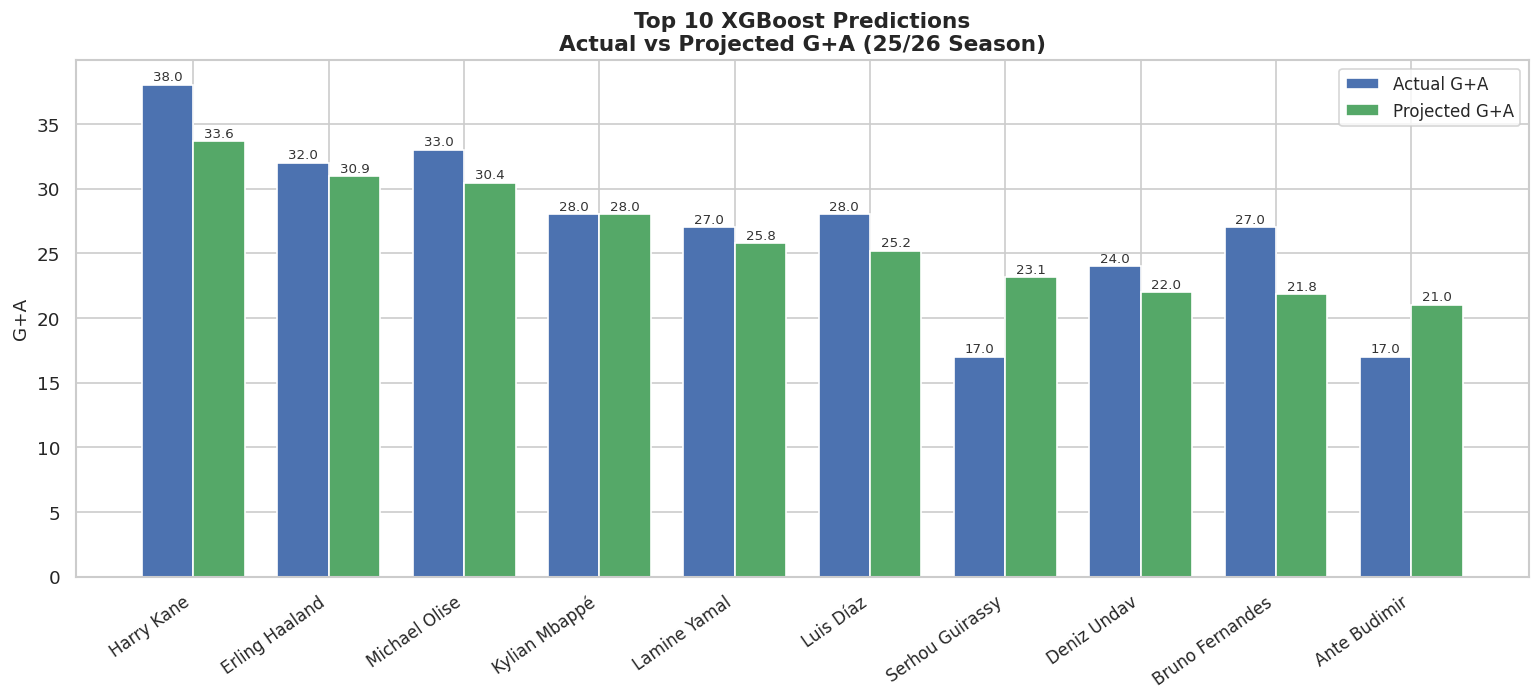

In [14]:
top10 = global_results_xgb.sort_values('Projected_G+A', ascending=False).head(10).copy()

x = range(len(top10))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar([i - width/2 for i in x], top10['Target_G+A'],  width, label='Actual G+A',    color='#4C72B0', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], top10['Projected_G+A'], width, label='Projected G+A', color='#55A868', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(top10['Player'], rotation=35, ha='right', fontsize=10)
ax.set_ylabel('G+A', fontsize=11)
ax.set_title('Top 10 XGBoost Predictions\nActual vs Projected G+A (25/26 Season)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Annotate
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='#333')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='#333')

plt.tight_layout()
plt.savefig('top10_predictions.png', bbox_inches='tight')
plt.show()


### 7️⃣ Full Evaluation Metrics Summary

In [15]:
summary_rows = []

for name, df in [('Random Forest', results), ('Gradient Boosting', test_results_gb), ('XGBoost', test_results_xgb)]:
    actual    = df['Target_G+A']
    predicted = df['Projected_G+A']
    summary_rows.append({
        'Model':   name,
        'MAE':     round(mean_absolute_error(actual, predicted), 4),
        'RMSE':    round(mean_squared_error(actual, predicted) ** 0.5, 4),
        'R²':      round(r2_score(actual, predicted), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('='*55)
print('         MODEL EVALUATION SUMMARY (TEST SET)')
print('='*55)
print(summary_df.to_string())
print('='*55)

best_model = summary_df['MAE'].idxmin()
print(f'\n✅ Best Model by MAE: {best_model} ({summary_df.loc[best_model, "MAE"]} G+A off on average)')


         MODEL EVALUATION SUMMARY (TEST SET)
                      MAE    RMSE      R²
Model                                    
Random Forest      1.6705  2.5736  0.7155
Gradient Boosting  1.6531  2.5758  0.7150
XGBoost            1.6710  2.6143  0.7064

✅ Best Model by MAE: Gradient Boosting (1.6531 G+A off on average)
